In [20]:
import time
from datetime import datetime, timedelta

import ccxt
import matplotlib.pyplot as plt
import ta
import pandas as pd

print(ccxt.exchanges)

exchange = ccxt.hyperliquid()

['alp', 'alpaca', 'apex', 'arkham', 'ascendex', 'aster', 'backpack', 'bequant', 'bigone', 'binance', 'binancecoinm', 'binanceus', 'binanceusdm', 'bingx', 'bit2c', 'bitbank', 'bitbns', 'bitfinex', 'bitflyer', 'bitget', 'bithumb', 'bitmart', 'bitmex', 'bitopro', 'bitrue', 'bitso', 'bitstamp', 'bitteam', 'bittrade', 'bitvavo', 'blockchaincom', 'blofin', 'btcbox', 'btcmarkets', 'btcturk', 'bullish', 'bybit', 'bydfi', 'cex', 'coinbase', 'coinbaseadvanced', 'coinbaseexchange', 'coinbaseinternational', 'coincatch', 'coincheck', 'coinex', 'coinmate', 'coinmetro', 'coinone', 'coinsph', 'coinspot', 'cryptocom', 'cryptomus', 'deepcoin', 'defx', 'delta', 'deribit', 'derive', 'digifinex', 'dydx', 'exmo', 'fmfwio', 'foxbit', 'gate', 'gateio', 'gemini', 'hashkey', 'hibachi', 'hitbtc', 'hollaex', 'htx', 'huobi', 'hyperliquid', 'independentreserve', 'indodax', 'kraken', 'krakenfutures', 'kucoin', 'kucoinfutures', 'latoken', 'lbank', 'luno', 'mercado', 'mexc', 'modetrade', 'myokx', 'ndax', 'novadax', 'o

In [22]:
def to_dataframe(candles: list[list[float]]) -> pd.DataFrame:
    df = pd.DataFrame(
        candles, columns=["datetime", "open", "high", "low", "close", "volume"]
    )
    df["datetime"] = pd.to_datetime(df["datetime"], unit="ms")
    df = df.set_index("datetime").sort_index()

    return df


def fetch_ohlcv_range(
    symbol: str,
    timeframe: str,
    start_ts_ms: int,
    end_ts_ms: int,
    exchange: ccxt.Exchange,
) -> pd.DataFrame:
    all_candles: list[list[float]] = []
    current_since = start_ts_ms
    limit = 100

    while current_since < end_ts_ms:
        candles = exchange.fetch_ohlcv(
            symbol=symbol, timeframe=timeframe, since=current_since, limit=limit
        )
        if not candles:
            break

        all_candles.extend(candles)

        last_ts = candles[-1][0]
        if last_ts >= end_ts_ms:
            break

        current_since = last_ts + 1

        time.sleep(1)

    return to_dataframe(all_candles)


now = datetime.now().replace(minute=15, second=0, microsecond=0)
since = int((now - timedelta(days=30)).timestamp() * 1000)
end = int(now.timestamp() * 1000)
symbol = "SOL/USDC:USDC"
timeframe = "15m"

df = fetch_ohlcv_range(
    symbol=symbol,
    timeframe=timeframe,
    start_ts_ms=since,
    end_ts_ms=end,
    exchange=exchange,
)
df = df[df.index < now]
print(df.head())
df.to_csv(f"{symbol.replace('/', '_')}_{timeframe}_{since}_{end}.csv")

                       open    high     low   close     volume
datetime                                                      
2026-01-23 14:15:00  127.03  127.21  126.92  127.20   12497.92
2026-01-23 14:30:00  127.20  127.28  125.47  125.65  119565.82
2026-01-23 14:45:00  125.66  126.18  125.22  126.03   79652.31
2026-01-23 15:00:00  126.03  126.30  125.69  125.78   24826.76
2026-01-23 15:15:00  125.79  126.68  125.43  126.40   63416.82


In [17]:
window_atr = 10
window_vwap = 14

df['bar_portion'] = (df['close'] - df['open']) / (df['high'] - df['low'])
df['bar_position'] = (((df['open'] + df['close']) / 2) - df['low']) / (df['high'] - df['low'])

atr = ta.volatility.AverageTrueRange(df['high'], df['low'], df['close'], window=window_atr)
df['atr'] = atr.average_true_range()

df['stick_length'] = (df['high'] - df['low']) / df['atr'].shift(1)
df['slope'] = (df['close'] - df['close'].shift(1)) / df['close'].shift(1)

df['curvature'] = df['slope'] - df['slope'].shift(1)

vwap = ta.volume.VolumeWeightedAveragePrice(df['high'], df['low'], df['close'], df['volume'], window=window_vwap)
df['vwap'] = vwap.volume_weighted_average_price()

df['vwap_deviation'] = (df['vwap'] - df['close']) / df['close']
df = df.dropna()

print(df.tail())

                        open     high      low    close   volume  bar_portion  \
datetime                                                                        
2026-02-22 11:49:00  68153.0  68154.0  68152.0  68153.0  2.42129     0.000000   
2026-02-22 11:50:00  68154.0  68154.0  68153.0  68153.0  0.42478    -1.000000   
2026-02-22 11:51:00  68153.0  68165.0  68153.0  68164.0  2.33940     0.916667   
2026-02-22 11:52:00  68164.0  68165.0  68164.0  68165.0  0.57186     1.000000   
2026-02-22 11:53:00  68165.0  68165.0  68164.0  68165.0  0.18775     0.000000   

                     bar_position       atr  stick_length     slope  \
datetime                                                              
2026-02-22 11:49:00      0.500000  6.765190      0.274173  0.000000   
2026-02-22 11:50:00      0.500000  6.188671      0.147816  0.000000   
2026-02-22 11:51:00      0.458333  6.769804      1.939027  0.000161   
2026-02-22 11:52:00      0.500000  6.192824      0.147715  0.000015   
2026-0

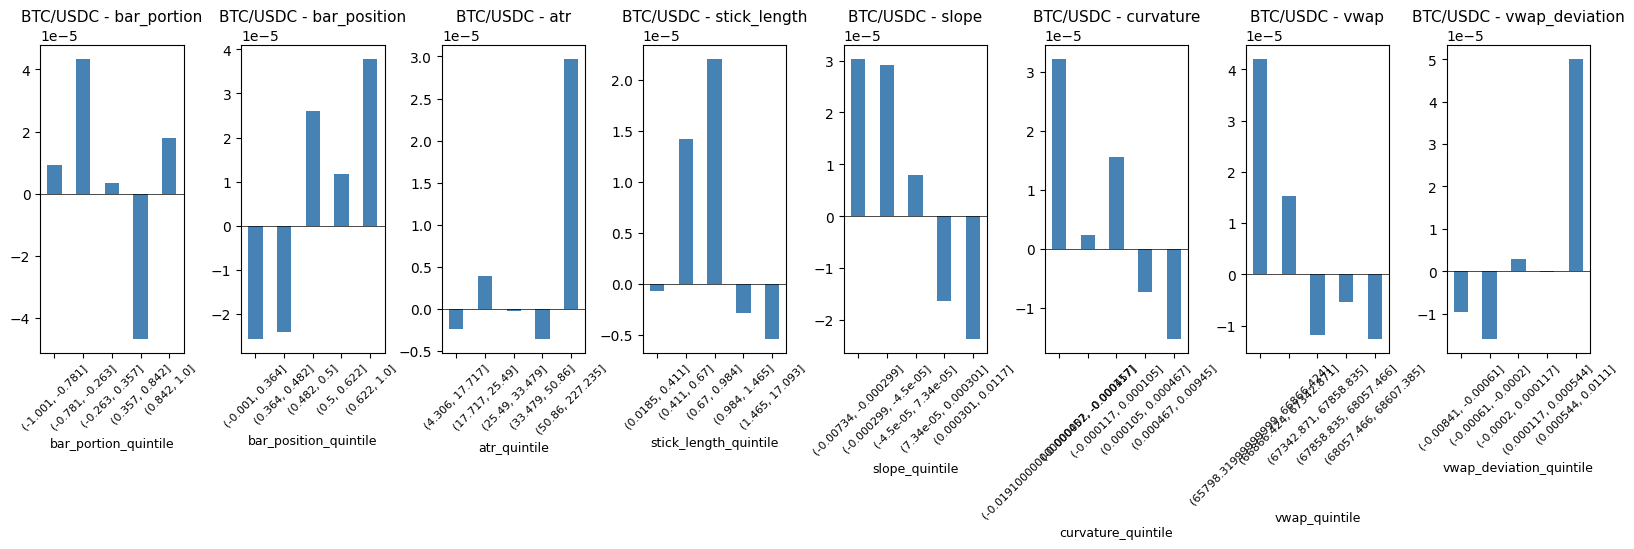

In [18]:
df['target_fwd_return'] = df['close'].shift(-1) / df['close'] - 1
df_clean = df.dropna().copy()

signals = ['bar_portion', 'bar_position', 'atr', 'stick_length', 'slope', 'curvature', 'vwap', 'vwap_deviation']

fig, axes = plt.subplots(1, len(signals), figsize=(20, 4))
plt.subplots_adjust(wspace=0.4)

for i, signal in enumerate(signals):
    col_quintile = f"{signal}_quintile"
    df_clean[col_quintile] = pd.qcut(df_clean[signal], q=5, duplicates='drop')

    quintile_analysis = df_clean.groupby(col_quintile)['target_fwd_return'].mean()

    ax = axes[i]
    quintile_analysis.plot(kind='bar', ax=ax, color='steelblue')

    ax.set_title(f"BTC/USDC - {signal}", fontsize=11)
    ax.set_xlabel(f"{signal}_quintile", fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

plt.show()